# Tesla Stock Price Analysis and Forecasting

This notebook performs an in-depth analysis of Tesla stock prices, exploring key metrics, technical indicators, and applying time series forecasting models like ARIMA and LSTM. The goal is to understand how Tesla’s stock behaves, identify important trends, and forecast future price movements.

---

## 1. **Importing Necessary Libraries**

We begin by importing the essential libraries required for data manipulation, visualization, and modeling. These libraries include:

- **Pandas** for data manipulation and analysis
- **NumPy** for numerical operations
- **Matplotlib and Seaborn** for data visualization
- **mplfinance** for creating candlestick charts
- **Statsmodels** and **pmdarima** for time series modeling (ARIMA)
- **TensorFlow/Keras** for building and training machine learning models (LSTM)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import mplfinance as mpf
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import warnings
warnings.filterwarnings('ignore')

/Users/lokeshreddy/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (
/Users/lokeshreddy/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 2. **Data Collection & Exploration**

In this step, we load the Tesla stock data (historical stock prices) from a CSV file. The data includes columns such as Date, Open, High, Low, Close, Volume, etc. 

### Data Overview:

We will:
- Display the first few rows to get an overview of the data
- Check for missing values, data types, and basic statistics
- Identify any duplicated entries


In [2]:
df = pd.read_csv("/Users/lokeshreddy/Downloads/TSLA.xls",parse_dates=True,index_col='Date')
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500


In [3]:
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2956 entries, 2010-06-29 to 2022-03-24
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2956 non-null   float64
 1   High       2956 non-null   float64
 2   Low        2956 non-null   float64
 3   Close      2956 non-null   float64
 4   Adj Close  2956 non-null   float64
 5   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 161.7 KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,1229.910034,3.046940e+08


In [6]:
df.duplicated().sum()

0

## 3. **Data Cleaning & Preprocessing**

Before performing any analysis, we must ensure that the dataset is ready. This may involve:
- Converting columns to appropriate data types 
- Handling missing values or other anomalies, if any


In [7]:
df = df.astype(float)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500.0
2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500.0
2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000.0
2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000.0
2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500.0
...,...,...,...,...,...,...
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500.0
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200.0
2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500.0


## 4. **Exploratory Data Analysis (EDA)**

### Visualizations

#### Visualizing Tesla's Stock Price Over Time

A key part of the analysis is visualizing how Tesla's stock price has moved over time. We'll create a line plot of the closing price to observe the overall trend.

**Closing Price Plot**

The closing price is often used to assess the stock's overall performance and is a key indicator for investors.

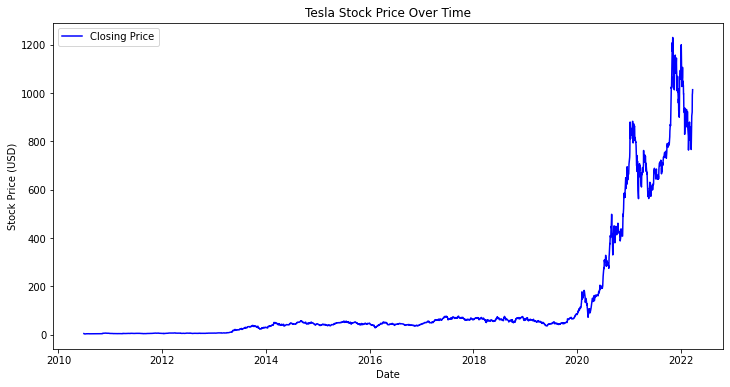

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Closing Price', color='blue')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.title('Tesla Stock Price Over Time')
plt.legend()
plt.show()

**Interpretation:**

The plot will help us identify whether Tesla’s stock price has been on an upward or downward trajectory over time, and whether there are any sharp fluctuations or trends.

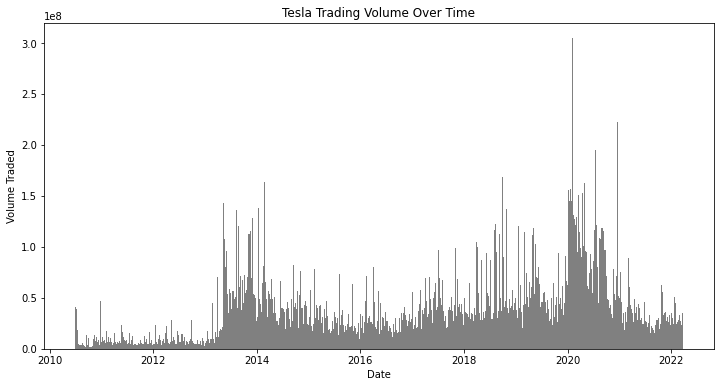

In [9]:
plt.figure(figsize=(12, 6))
plt.bar(df.index, df['Volume'], color='gray', width=5)
plt.xlabel('Date')
plt.ylabel('Volume Traded')
plt.title('Tesla Trading Volume Over Time')
plt.show()

#### Analyzing Daily Price Range

**Daily Price Range Calculation**

The daily price range is calculated by subtracting the low price from the high price for each day. This gives us an idea of the stock's volatility—how much the price fluctuated within a day.

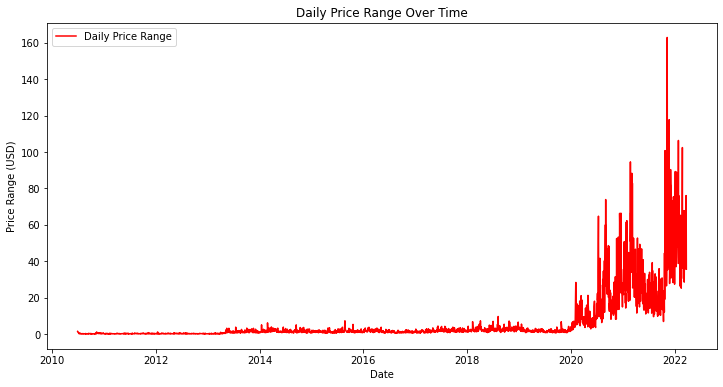

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['High'] - df['Low'], label='Daily Price Range', color='red')
plt.xlabel('Date')
plt.ylabel('Price Range (USD)')
plt.title('Daily Price Range Over Time')
plt.legend()
plt.show()

**Interpretation:**

A wider price range suggests greater volatility, indicating that the stock's price fluctuated more within the day. This information can help investors assess the risk associated with Tesla stock.

    Higher range → More volatile days 🔥
    Lower range → Calm, stable trading 🌊

#### Calculating Price Change Percentage

The percentage change in the stock price helps us understand how the price has moved relative to its previous day's value. A high positive or negative value indicates a significant change, while values close to zero suggest little price movement.

    If +% → Stock rose 📈
    If -% → Stock fell 📉

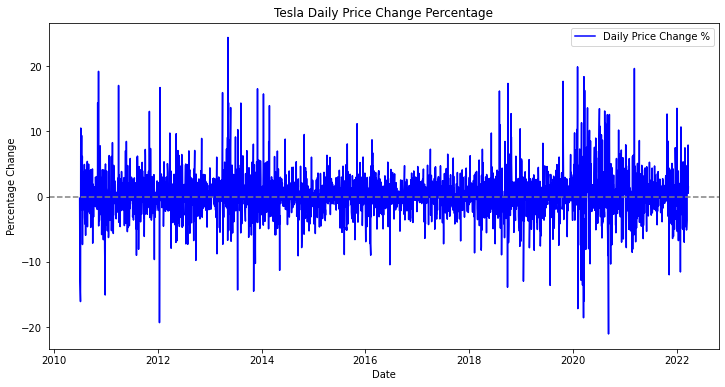

In [11]:
df['Price Change %'] = df['Close'].pct_change() * 100  # Convert to percentage
plt.figure(figsize=(12, 6))
plt.plot(df['Price Change %'], label='Daily Price Change %', color='blue')
plt.axhline(0, linestyle='--', color='gray')  # Reference line at 0%
plt.xlabel('Date')
plt.ylabel('Percentage Change')
plt.title('Tesla Daily Price Change Percentage')
plt.legend()
plt.show()

**Interpretation:**

The plot will help identify days with significant price movement (either up or down). Understanding these movements can provide insights into market sentiment or events affecting the stock price.

    Big spikes → High movement days.
    Near 0% → Low activity days.

#### Box Plot for Tesla's Closing Prices

A box plot helps to visualize the distribution of Tesla’s closing prices, showing the median, quartiles, and outliers. This gives an overview of how concentrated or dispersed the stock price is.


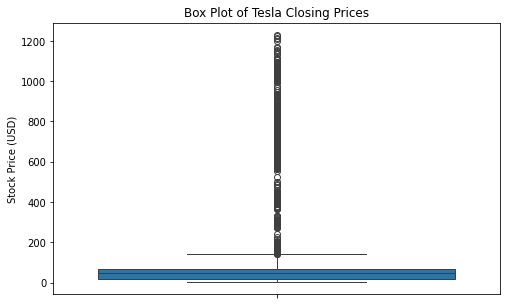

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Close'])
plt.title('Box Plot of Tesla Closing Prices')
plt.ylabel('Stock Price (USD)')
plt.show()

**Interpretation:**

The box plot allows us to quickly assess the spread of Tesla's closing prices. Outliers or extreme price movements are also clearly visible in this plot.

## 4. **Feature Engineering**

### Candlestick Chart for Detailed Price Movements

**Why Candlestick Charts?**

A candlestick chart visually represents a stock's opening, closing, highest, and lowest prices for each trading day.  It helps traders identify market trends, reversals, and patterns such as bullish/bearish movements.

**How It Works?**

Each candle has four key price points:

*   **Open:** Price at the start of the trading session.
*   **Close:** Price at the end of the session.
*   **High:** Highest price in that session.
*   **Low:** Lowest price in that session.

A green (bullish) candle means the closing price is higher than the opening price.

A red (bearish) candle means the closing price is lower than the opening price.

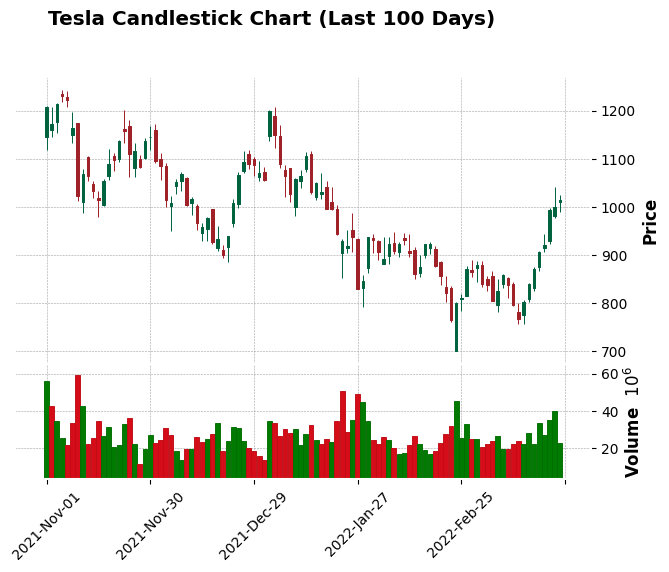

In [13]:
import mplfinance as mpf

# Plot candlestick chart
mpf.plot(df[-100:], type='candle', volume=True, style='charles', 
         title="Tesla Candlestick Chart (Last 100 Days)")


**Interpretation:**

Candlestick patterns can reveal potential price trends. For example, consecutive long bullish candlesticks could signal an uptrend, while bearish candlesticks may suggest a downtrend.

### Stock Returns Calculation & Analysis

**Why Calculate Returns?**

Stock returns provide insights into the percentage change in stock prices on a daily basis, allowing us to measure the stock's volatility and performance.

**How It Works?**

**Daily Return Formula:**

Daily Return = (Today's Closing Price - Yesterday's Closing Price) / Yesterday's Closing Price

Or, equivalently:

Daily Return = (Today's Closing Price / Yesterday's Closing Price) - 1

*   Positive returns → Stock price increased.
*   Negative returns → Stock price decreased.


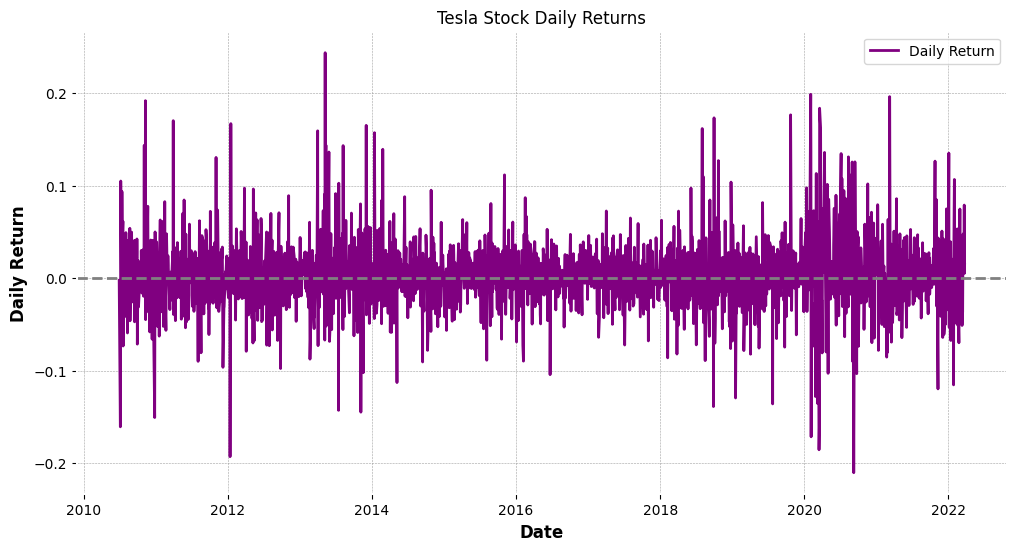

In [14]:
df['Daily Return'] = df['Close'].pct_change()

# Plot Daily Returns
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Daily Return'], label='Daily Return', color='purple')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.title('Tesla Stock Daily Returns')
plt.legend()
plt.show()

**Interpretation:**

This plot visualizes the daily returns of Tesla's stock, which can help investors identify patterns of positive or negative performance over time.

### Volatility Analysis

**Why Analyze Volatility?**

Volatility is an important metric to assess the risk associated with a stock. Higher volatility means greater potential for large price changes, while lower volatility suggests more stability.

 
    High volatility means large price swings (good for traders but risky for investors).
    Low volatility means stable stock movements (good for long-term investors).

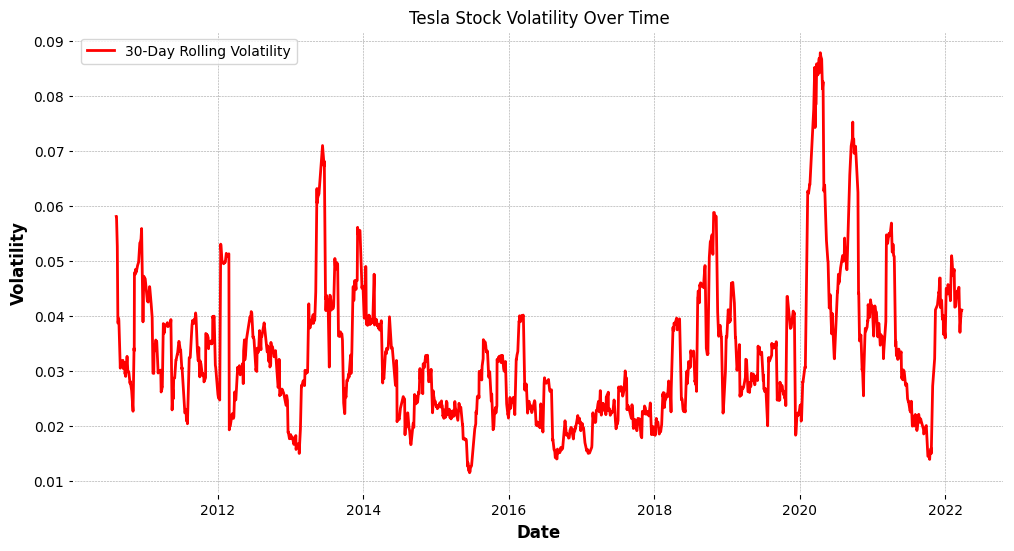

In [15]:
df['Volatility'] = df['Daily Return'].rolling(window=30).std()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Volatility'], label='30-Day Rolling Volatility', color='red')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.title('Tesla Stock Volatility Over Time')
plt.legend()
plt.show()

**Interpretation:**

Volatility can help assess how risky an investment in Tesla stock might be. The higher the volatility, the greater the risk, but potentially higher returns as well.

    If volatility increases suddenly, it might indicate a major market event or news impact.

### Correlation Between Trading Volume and Stock Price

**Why Study This Relationship?**

Trading volume shows how actively Tesla stock is bought and sold.
    
    If there’s a high correlation, it means higher trading activity impacts price movements.
   
    A low correlation suggests that price changes are independent of trading volume.

**How It Works?**

We use scatter plots to visualize the relationship.
    
The correlation coefficient (ranging from -1 to 1) quantifies the relationship:

        +1 → Strong positive correlation (High volume = Higher price).
        
        0 → No correlation (Volume and price move independently).
        
        -1 → Strong negative correlation (High volume = Lower price).

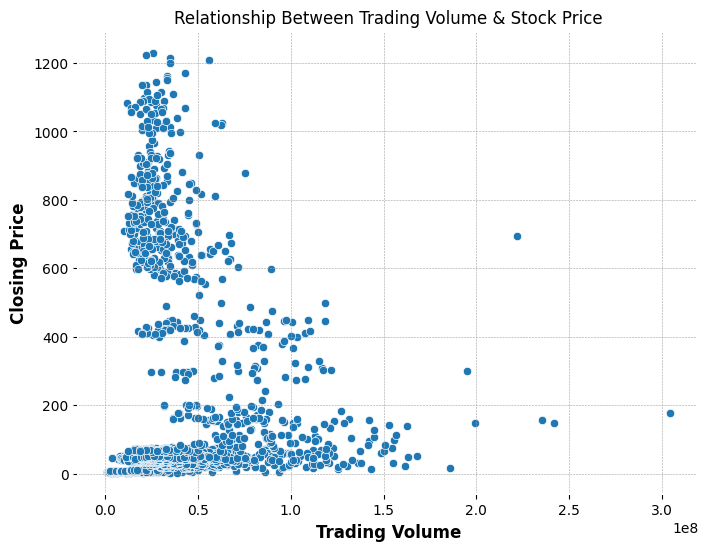

          Volume     Close
Volume  1.000000  0.090602
Close   0.090602  1.000000


In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Volume'], y=df['Close'])
plt.xlabel('Trading Volume')
plt.ylabel('Closing Price')
plt.title('Relationship Between Trading Volume & Stock Price')
plt.show()

# Calculate correlation
correlation = df[['Volume', 'Close']].corr()
print(correlation)

In [17]:
df

,Open,High,Low,Close,Adj Close,Volume,Price Change %,Daily Return,Volatility
Date,,,,,,,,,
2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500.0,NaN,NaN,NaN
2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500.0,-0.251151,-0.002512,NaN
2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000.0,-7.847251,-0.078473,NaN
2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000.0,-12.568306,-0.125683,NaN
2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500.0,-16.093750,-0.160937,NaN
...,...,...,...,...,...,...,...,...,...
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500.0,3.876783,0.038768,0.039161
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200.0,1.741786,0.017418,0.038734
2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500.0,7.905251,0.079053,0.041116


### Moving Averages (SMA & EMA)

**Why Moving Averages?**

Moving Averages smooth out price data to identify trends.

**Simple Moving Average (SMA):** Simple Moving Average, calculated as the mean of prices over a specified period (e.g., 50 or 200 days).
    
**Exponential Moving Average (EMA):** Similar to SMA but gives more weight to recent prices, making it more responsive.

In [18]:
df['SMA_50'] = df['Close'].rolling(window=50).mean()  # 50-day Simple Moving Average
df['SMA_200'] = df['Close'].rolling(window=200).mean()  # 200-day Simple Moving Average

df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()  # 50-day Exponential Moving Average
df['EMA_200'] = df['Close'].ewm(span=200, adjust=False).mean()  # 200-day Exponential Moving Average

In [19]:
df

,Open,High,Low,Close,Adj Close,Volume,Price Change %,Daily Return,Volatility,SMA_50,SMA_200,EMA_50,EMA_200
Date,,,,,,,,,,,,,
2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500.0,NaN,NaN,NaN,NaN,NaN,4.778000,4.778000
2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500.0,-0.251151,-0.002512,NaN,NaN,NaN,4.777529,4.777881
2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000.0,-7.847251,-0.078473,NaN,NaN,NaN,4.762411,4.774041
2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000.0,-12.568306,-0.125683,NaN,NaN,NaN,4.726238,4.764747
2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500.0,-16.093750,-0.160937,NaN,NaN,NaN,4.667248,4.749396
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500.0,3.876783,0.038768,0.039161,903.872197,851.032347,890.970712,856.444265
2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200.0,1.741786,0.017418,0.038734,901.001398,852.642897,892.154604,857.088203
2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500.0,7.905251,0.079053,0.041116,900.341798,854.587147,896.147756,858.450310


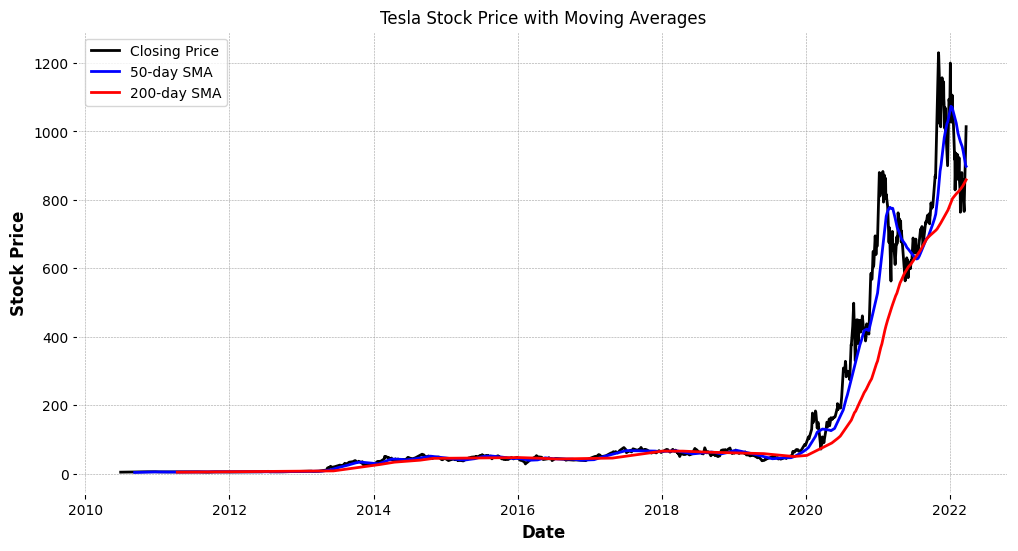

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Closing Price', color='black')
plt.plot(df['SMA_50'], label='50-day SMA', color='blue')
plt.plot(df['SMA_200'], label='200-day SMA', color='red')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Tesla Stock Price with Moving Averages')
plt.legend()
plt.show()

**Interpretation:**

If the SMA 50 crosses above SMA 200 → Bullish trend 🟢
If the SMA 50 crosses below SMA 200 → Bearish trend 🔴

### Relative Strength Index (RSI)

**Analyzing Momentum with RSI**

RSI is used to measure the momentum of a stock. It oscillates between 0 and 100, and values above 70 typically indicate an overbought condition (stock may be overpriced), while values below 30 suggest the stock is oversold.

In [21]:
window = 14  # Standard RSI window

# Compute price change
delta = df['Close'].diff()

# Separate gains and losses
gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

# Compute Relative Strength (RS)
RS = gain / loss
df['RSI'] = 100 - (100 / (1 + RS))  # RSI formula

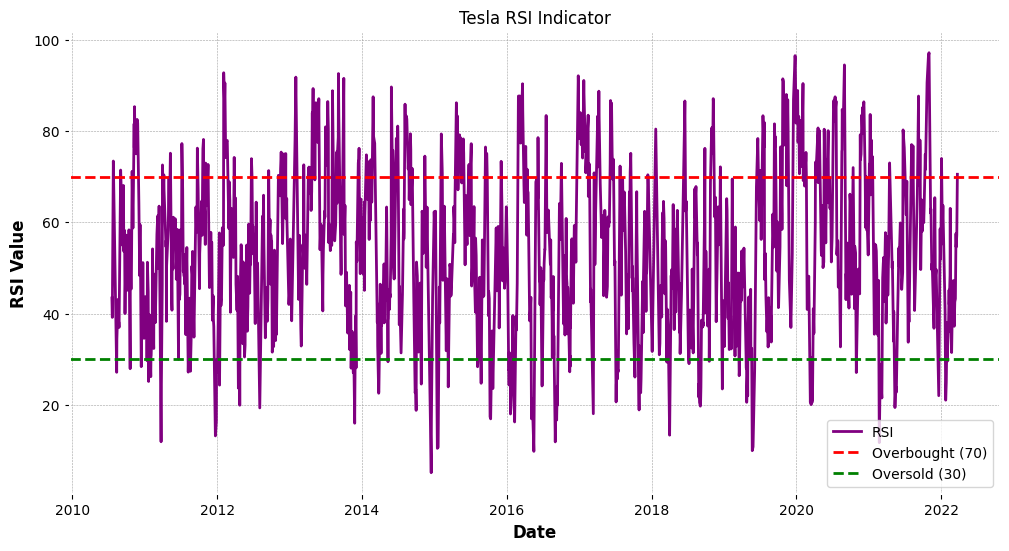

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(df['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', color='green', label='Oversold (30)')
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.title('Tesla RSI Indicator')
plt.legend()
plt.show()

**Interpretation:**

By looking at the RSI plot, you can identify overbought or oversold conditions, which could provide buy or sell signals.

### Bollinger Bands (BB)

**Why Bollinger Bands?**

Bollinger Bands consist of:

 - Middle Band: The 20-day moving average
 - Upper and Lower Bands: The upper and lower limits based on the standard deviation of prices
    

Measures volatility using moving averages.

    Upper band = Overbought
    
    Lower band = Oversold
    

In [23]:
df['Middle Band'] = df['Close'].rolling(window=20).mean()  # 20-day moving average
df['Upper Band'] = df['Middle Band'] + (df['Close'].rolling(window=20).std() * 2)
df['Lower Band'] = df['Middle Band'] - (df['Close'].rolling(window=20).std() * 2)

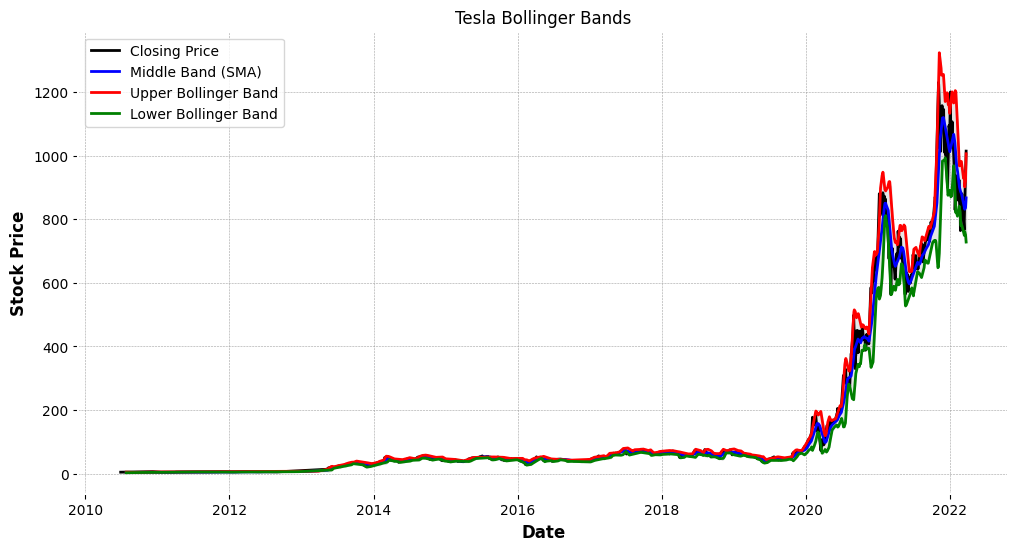

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Closing Price', color='black')
plt.plot(df['Middle Band'], label='Middle Band (SMA)', color='blue')
plt.plot(df['Upper Band'], label='Upper Bollinger Band', color='red')
plt.plot(df['Lower Band'], label='Lower Bollinger Band', color='green')
plt.fill_between(df.index, df['Lower Band'], df['Upper Band'], color='gray', alpha=0.2)  # Shading area
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Tesla Bollinger Bands')
plt.legend()
plt.show()

**Interpretation:**

When the price reaches the upper band, it is considered overbought, and when it reaches the lower band, it is considered oversold. The distance between the bands indicates stock volatility.

    Price touches Upper Band → Possible reversal downward 🔻
    Price touches Lower Band → Possible reversal upward 🔺

## 4. **Time Series Forecasting**

### Forecasting Using ARIMA (Autoregressive Integrated Moving Average)

ARIMA (AutoRegressive Integrated Moving Average) is a time series forecasting model that uses past data points to predict future values.ARIMA is a widely used for short-term forecasting.

**Step 1: Check for Stationarity**

A stationary time series has a constant mean and variance, which ARIMA requires.

In [25]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
result = adfuller(df['Close'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])  # If p-value < 0.05, data is stationary

if result[1] > 0.05:
    print("Time series is NOT stationary, differencing needed.")
else:
    print("Time series is stationary.")

ADF Statistic: 1.423941593922597
p-value: 0.9972202364261444
Time series is NOT stationary, differencing needed.


**📌Interpretation:** 

If p-value > 0.05, the data is non-stationary. Apply differencing.

In [26]:
df['Close_diff'] = df['Close'].diff().dropna()

**Step 2: Fit ARIMA Model**

We use the auto_arima function to find the best ARIMA parameters (p, d, q).

In [27]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

# Auto-select ARIMA parameters
best_model = auto_arima(df['Close'], seasonal=False, trace=True, suppress_warnings=True)

# Fit ARIMA model
model = ARIMA(df['Close'], order=best_model.order)
arima_fit = model.fit()

# Predict next 30 days
future_forecast = arima_fit.forecast(steps=30)
print(future_forecast)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=2.19 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=24729.972, Time=0.04 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=23897.367, Time=0.10 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.78 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=24727.973, Time=0.03 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=23496.717, Time=0.10 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=23301.138, Time=0.46 sec
 ARIMA(4,2,0)(0,0,0)[0] intercept   : AIC=23157.862, Time=0.94 sec
 ARIMA(5,2,0)(0,0,0)[0] intercept   : AIC=23088.407, Time=1.00 sec
 ARIMA(5,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=3.86 sec
 ARIMA(4,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=2.73 sec
 ARIMA(5,2,0)(0,0,0)[0]             : AIC=23086.429, Time=0.78 sec
 ARIMA(4,2,0)(0,0,0)[0]             : AIC=23155.877, Time=0.45 sec
 ARIMA(5,2,1)(0,0,0)[0]             : AIC=inf, Time=1.33 sec
 ARIMA(4,2,1)(0,0,0)[0]             : AIC=inf, Ti

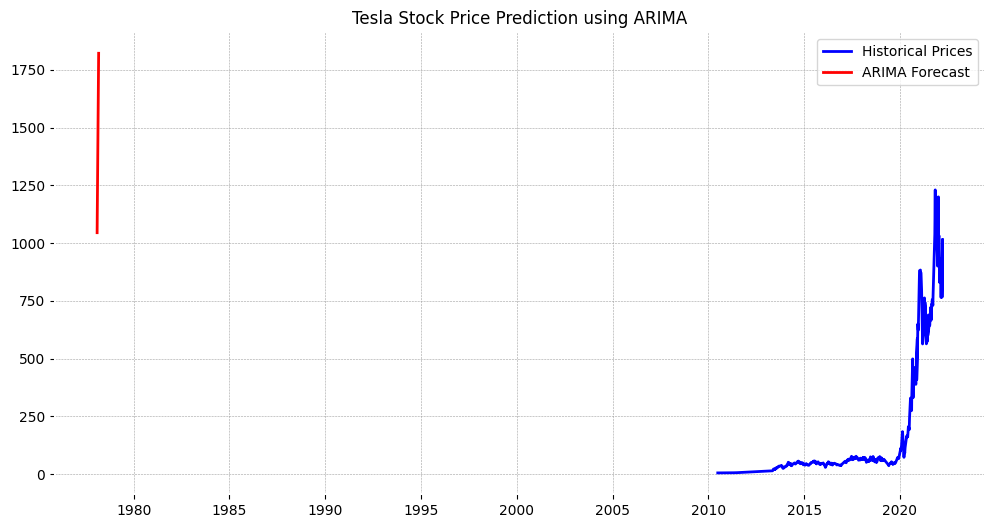

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label="Historical Prices", color="blue")
plt.plot(future_forecast, label="ARIMA Forecast", color="red")
plt.legend()
plt.title("Tesla Stock Price Prediction using ARIMA")
plt.show()

**Interpretation:**

The forecasted prices provide insight into where Tesla's stock might be headed in the short term. This model relies on past price patterns, so it assumes that historical trends will continue.

### Forecasting Using LSTM (Long Short-Term Memory)

LSTMs are deep learning models designed for sequential data like stock prices.

**Step 1: Data Preprocessing for LSTM**

We normalize data for better training:

In [29]:
from sklearn.preprocessing import MinMaxScaler

# Scale prices between 0 and 1
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

# Create sequences of past 60 days to predict next day
X_train, y_train = [], []
for i in range(60, len(scaled_data)):
    X_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))  # Reshape for LSTM


**Step 2: Build & Train LSTM Model**

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Build LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))  # Output layer (next day's price)

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=32)


Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0111
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0013
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0011
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 8.3598e-04
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 9.5098e-04
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 7.6613e-04
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 8.4457e-04
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 6.1469e-04
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 7.7713e-04
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 7.7145e-04
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 9.2139e-04
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 9.3197e-04
Epoch 13/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 6.6712e-04
Epoch 14/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 6.2691e-04
Epoch 15/20
91/91 ━━━━━━━━━

**Step 3: Predict Future Prices**

In [31]:
# Prepare test data (last 60 days)
test_inputs = df['Close'].values[-60:]
test_inputs = scaler.transform(test_inputs.reshape(-1,1))

X_test = []
X_test.append(test_inputs)
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Predict
predicted_price = model.predict(X_test)
predicted_price = scaler.inverse_transform(predicted_price)  # Convert back to real scale
print(f"Predicted Next Day Price: ${predicted_price[0][0]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Predicted Next Day Price: $980.66


### Model Evaluation: Compare ARIMA vs LSTM

To compare the models, we calculate **Root Mean Squared Error (RMSE):**

In [32]:
from sklearn.metrics import mean_squared_error

# ARIMA RMSE
arima_rmse = np.sqrt(mean_squared_error(df['Close'][-30:], future_forecast))

# LSTM RMSE
y_test_actual = df['Close'][-30:].values  # Last 30 actual prices
y_test_predicted = model.predict(X_train[-30:])  # LSTM Predictions
y_test_predicted = scaler.inverse_transform(y_test_predicted)

lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_predicted))

print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"LSTM RMSE: {lstm_rmse:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
ARIMA RMSE: 611.70
LSTM RMSE: 58.64


**📌Interpretation:**

Lower RMSE = Better Model Performance

- If ARIMA RMSE < LSTM RMSE, ARIMA is better.
    
- If LSTM RMSE < ARIMA RMSE, LSTM is better.

## 5. **Applying Trading Strategies Based on Indicators**

Now that we have created technical indicators like **Moving Averages (SMA, EMA), RSI, Bollinger Bands, Daily Price Range, and Price Change Percentage**, we can use them to develop **trading strategies**. In this step, we will:

1. Define Buy & Sell Signals based on indicators.
2. Backtest the Strategy (Simulating trades).
3. Analyze Strategy Performance using profit/loss.
4. Visualize Buy & Sell points on the stock chart.

### Define Buy & Sell Rules

Let’s create trading rules based on our indicators:

- **Moving Average Crossover:** Buy when **SMA 50 crosses above SMA 200 (Golden Cross)**. Sell when **SMA 50 crosses below SMA 200 (Death Cross)**.
- **RSI Strategy:** Buy if **RSI < 30 (Oversold)**. Sell if **RSI > 70 (Overbought)**.
- **Bollinger Bands Strategy:** Buy if the **price touches the Lower Band**, Sell if it touches the **Upper Band.**

**Implement Trading Signals**

In [33]:
# Initialize Buy & Sell columns
df['Buy_Signal'] = 0
df['Sell_Signal'] = 0

# Moving Average Crossover Strategy
df.loc[(df['SMA_50'] > df['SMA_200']) & (df['SMA_50'].shift(1) <= df['SMA_200'].shift(1)), 'Buy_Signal'] = 1
df.loc[(df['SMA_50'] < df['SMA_200']) & (df['SMA_50'].shift(1) >= df['SMA_200'].shift(1)), 'Sell_Signal'] = 1

# RSI Strategy
df.loc[df['RSI'] < 30, 'Buy_Signal'] = 1
df.loc[df['RSI'] > 70, 'Sell_Signal'] = 1

# Bollinger Bands Strategy
df.loc[df['Close'] <= df['Lower Band'], 'Buy_Signal'] = 1
df.loc[df['Close'] >= df['Upper Band'], 'Sell_Signal'] = 1


**Plottting Buy & Sell Signals on Stock Chart**

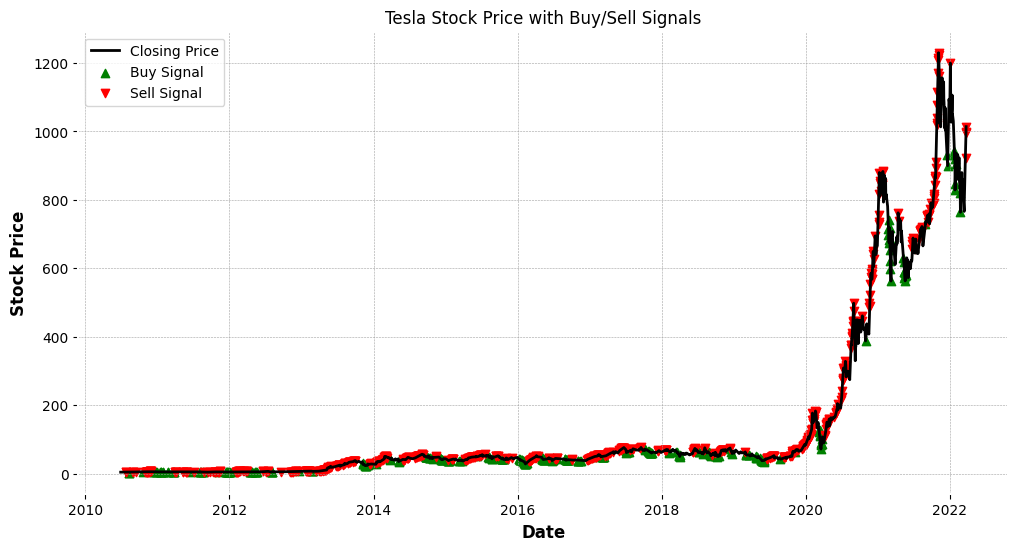

In [34]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Closing Price', color='black')

# Plot Buy Signals
plt.scatter(df.index[df['Buy_Signal'] == 1], df['Close'][df['Buy_Signal'] == 1], label='Buy Signal', marker='^', color='green', alpha=1)

# Plot Sell Signals
plt.scatter(df.index[df['Sell_Signal'] == 1], df['Close'][df['Sell_Signal'] == 1], label='Sell Signal', marker='v', color='red', alpha=1)

plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.title('Tesla Stock Price with Buy/Sell Signals')
plt.legend()
plt.show()


**📌 Interpretation:**

- Green Arrows (↑) → Buy Signals 📈

- Red Arrows (↓) → Sell Signals 📉

### Backtesting the Strategy

To see if this strategy is profitable, we simulate **buying and selling** at detected points and compute total profit/loss.

In [35]:
# Simulate Trading: Track Buy/Sell Points
capital = 10000  # Starting money
position = 0  # No shares at the start
buy_price = 0  # To track buying price

for i in range(len(df)):
    if df['Buy_Signal'].iloc[i] == 1:  # Buy Condition
        position = capital / df['Close'].iloc[i]  # Buy as many shares as possible
        buy_price = df['Close'].iloc[i]
        capital = 0  # All money invested
    
    elif df['Sell_Signal'].iloc[i] == 1 and position > 0:  # Sell Condition
        capital = position * df['Close'].iloc[i]  # Sell all shares
        position = 0  # Reset position

# Final Portfolio Value
final_value = capital if capital > 0 else position * df['Close'].iloc[-1]
profit = final_value - 10000  # Compare with initial capital

print(f"Final Portfolio Value: ${final_value:.2f}")
print(f"Total Profit: ${profit:.2f}")


Final Portfolio Value: $0.00
Total Profit: $-10000.00


### Evaluating Strategy Performance

To measure the effectiveness of this trading strategy, we check:

- Win Rate → % of profitable trades.
- Max Drawdown → Worst loss before recovery.
- Sharpe Ratio → Risk-adjusted return.

#### Win Rate Calculation

In [36]:
 df['Trade_Profit'] = df['Close'].diff() * df['Buy_Signal']  # Profit per trade
win_trades = df['Trade_Profit'][df['Trade_Profit'] > 0].count()
loss_trades = df['Trade_Profit'][df['Trade_Profit'] < 0].count()

win_rate = win_trades / (win_trades + loss_trades) * 100
print(f"Win Rate: {win_rate:.2f}%")

Win Rate: 28.48%


**📌 Interpretation:**

- Win Rate > 50% → Strategy is working well.
- Win Rate < 50% → Needs improvement.

#### Max Drawdown Calculation

To assess the worst loss before recovery, we calculate the Maximum Drawdown (MDD), which represents the largest peak-to-trough decline before reaching a new peak.

In [37]:
# Calculate cumulative returns
df['Cumulative_Returns'] = (1 + df['Trade_Profit']).cumprod()

# Calculate running maximum of cumulative returns
df['Running_Max'] = df['Cumulative_Returns'].cummax()

# Calculate drawdown
df['Drawdown'] = df['Cumulative_Returns'] / df['Running_Max'] - 1

# Maximum Drawdown
max_drawdown = df['Drawdown'].min()
print(f"Max Drawdown: {max_drawdown:.2%}")

Max Drawdown: -65237.94%


**📌 Interpretation:**

- Lower Max Drawdown → Strategy is less risky.
- Higher Max Drawdown → Indicates potential risk of significant losses.

#### Sharpe Ratio Calculation

The Sharpe Ratio measures risk-adjusted return, helping compare the performance of different strategies by accounting for volatility.

In [38]:
# Calculate daily returns
df['Daily_Returns'] = df['Trade_Profit'] / df['Close'].shift(1)

# Compute Sharpe Ratio
risk_free_rate = 0.02  # Assuming 2% annual risk-free rate
trading_days = 252  # Approx. trading days in a year

excess_returns = df['Daily_Returns'].mean() - (risk_free_rate / trading_days)
std_dev = df['Daily_Returns'].std()

sharpe_ratio = (excess_returns / std_dev) * np.sqrt(trading_days)

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: -2.28


**📌 Interpretation:**
    
- Sharpe Ratio > 1 → Good risk-adjusted return.
- Sharpe Ratio > 2 → Strong risk-adjusted return.
- Sharpe Ratio < 1 → High volatility, lower returns.

**📌 Key Takeaways:**

- A high win rate with low drawdown suggests a stable and profitable strategy.
- A strong Sharpe ratio (> 2) confirms a good risk-adjusted return.
- If the win rate is low or drawdown is high, consider adjusting entry/exit signals or risk management rules.